<a href="https://colab.research.google.com/github/Hamtaro-chan/Customer-Income-and-Spending-Behavior-Analysis/blob/main/Customer_Income_and_Spending_Behavior_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Income and Spending Behavior Analysis**

**Submitted by**:
Sirimintra Viboonkittanakorn 6481403

**Course**:
ICCS261 Principle of Data Science
Trimester 3 Academic Year 2023-2024

**Instructor**:
Ajarn Kritya Bunchongchit
Ajarn Phorutai Pearngam


In the competition of model retail, retailers continuously seek to understand and predict customer behavior to enhance customer satisfaction and optimise marketing strategies. Understanding customer behavior and preferences is crucial for supermarkets to maximise their profit.  By leveraging customer demographics, purchasing patterns, and preferences data, supermarkets can create targeted marketing campaigns, manage inventory effectively, and offer personalised shopping experiences. This project aims to analyse customer types and behaviors to determine which products are preferred by different customer segments, understand their purchasing patterns, and predict customer preferences.


## Introduction
The study delves into the influence of income and family size on customer spending patterns within a supermarket context, such as wine, meat, and fish.

**The research problem**: how do income levels and family size affect the number of products customers purchase?

**The rationale for the problems**: providing insights that can lead to improved marketing strategies and customer satisfaction.

**The objectives**: are to understand customer purchasing patterns and predict customer demographics and behaviors.


### The hypothesis
Customers with higher income levels and larger family sizes are more likely to spend more on supermarket products than customers with lower income levels and smaller family sizes.


### Data Description
Source: Kaggle dataset (https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis).

Data Overview: The dataset, sourced from Kaggle, comprises customer demographic information, purchasing behaviors, and responses to marketing campaigns. The key features include:



**Customer Personality**:
- Year_Birth: Customer's birth year
- Kidhome: Number of children in customer's household
- Income : Customer's yearly household income
Education: Customer's education level
-  Marital Status: Customer's marital status
- Teenhome: Number of teenagers in customer's household


**Purchasing Behaviors**:
- MntWines: Amount spent on wine in last 2 years
- MntFruits: Amount spent on fruits in last 2 years
- MntMeatProducts: Amount spent on meat in last 2 years
- MntFishProducts: Amount spent on fish in last 2 years
- MntSweetProducts: Amount spent on sweets in last 2 years
- MntGoldProds: Amount spent on gold in last 2 years


**Other**: Campaign Offer Acceptance


## Methodology
Data Preparation: cleaning the data by rearranging and dropping some of the redundant features


In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [92]:
#opening the date set
data = pd.read_csv("marketing_campaign.csv", sep="\t")
print(data)
data = data.dropna() #drop missing values
#cleaning the data by rearrange and grouping
data["Age"] = 2024-data["Year_Birth"]
data["Spent"] = data["MntWines"]+ data["MntFruits"]+ data["MntMeatProducts"]+ data["MntFishProducts"]+ data["MntSweetProducts"]+ data["MntGoldProds"]
data["Cohabit"]=data["Marital_Status"].replace({"Married":"Partner", "Together":"Partner", "Absurd":"Alone", "Widow":"Alone", "YOLO":"Alone", "Divorced":"Alone", "Single":"Alone",})
data["Children"]=data["Kidhome"]+data["Teenhome"]
data["no.member"] = data["Cohabit"].replace({"Alone": 1, "Partner":2})+ data["Children"]
data["Is_Parent"] = np.where(data.Children> 0, 1, 0)
data['Education'] = data['Education'].replace("Graduation",'Graduate')
data['Education'] = data['Education'].replace(['PhD', 'Master'],'Postgraduate')
data['Education'] = data['Education'].replace(['Basic','2n Cycle',], 'Undergraduate')
data['TotalAcceptedCmp'] = data['AcceptedCmp1'] + data['AcceptedCmp2'] + data['AcceptedCmp3'] + data['AcceptedCmp4'] + data['AcceptedCmp5']
#rename the produces' names
data=data.rename(columns={"MntWines": "Wines","MntFruits":"Fruits","MntMeatProducts":"Meat","MntFishProducts":"Fish","MntSweetProducts":"Sweets","MntGoldProds":"Gold"})
#dropping some of the redundant features
data = data.drop(["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID"], axis=1)
print(data)


         ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0            0  04-09-2012       58       635  ...            

/tmp/ipykernel_499/2643533215.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["no.member"] = data["Cohabit"].replace({"Alone": 1, "Partner":2})+ data["Children"]


## Exploratory Data Analysis (EDA)


**The level of education and expenses**


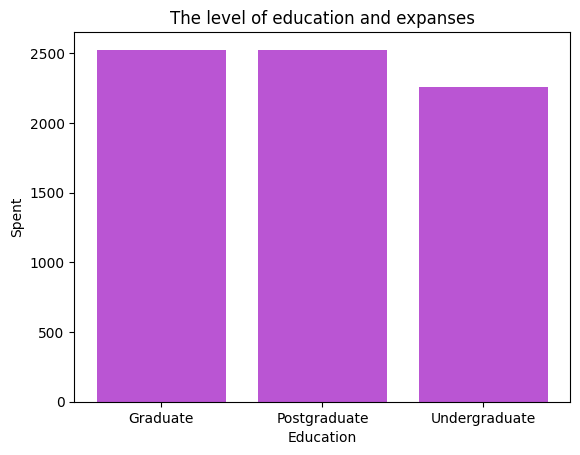

In [93]:
fig, ax = plt.subplots()
ax.bar(data['Education'],data['Spent'], color='mediumorchid')
ax.set(xlabel='Education', ylabel = 'Spent', title='The level of education and expanses')
plt.show()

**Age distribution**

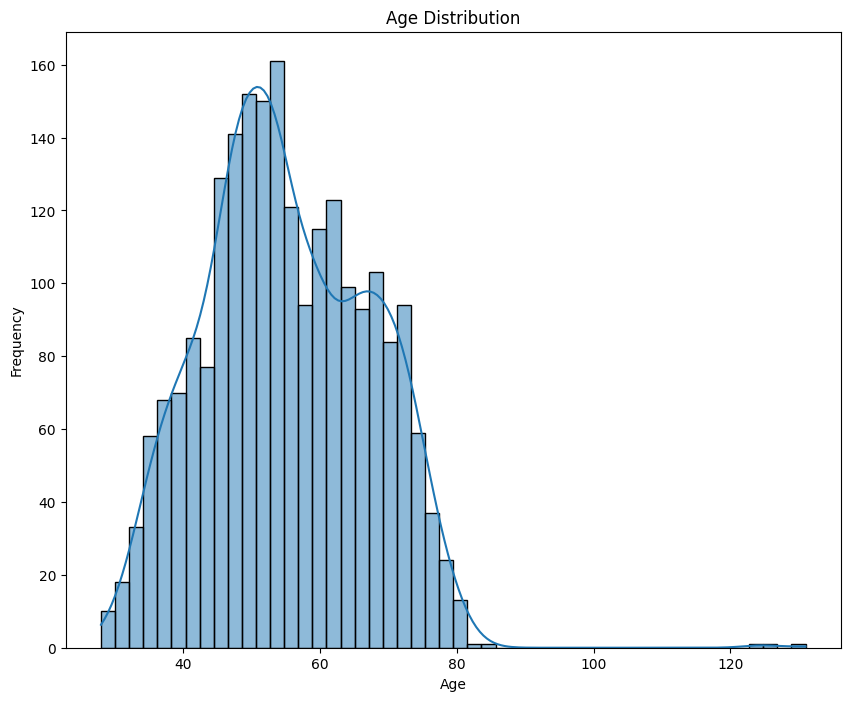

In [94]:
plt.figure(figsize=(10, 8))
sns.histplot(data['Age'], bins=50, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

**Income distribution plot**

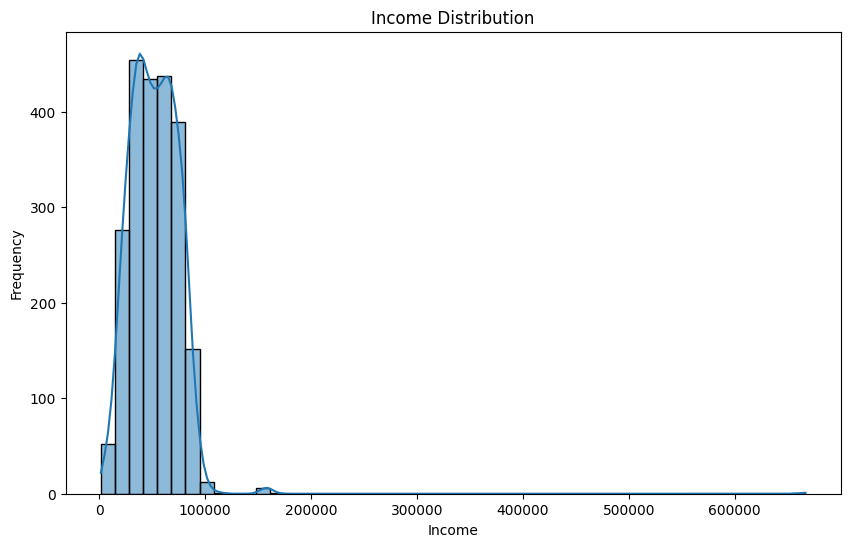

In [95]:
plt.figure(figsize=(10, 6))
sns.histplot(data['Income'], bins=50, kde=True)
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

**Amount spent on different product categories**

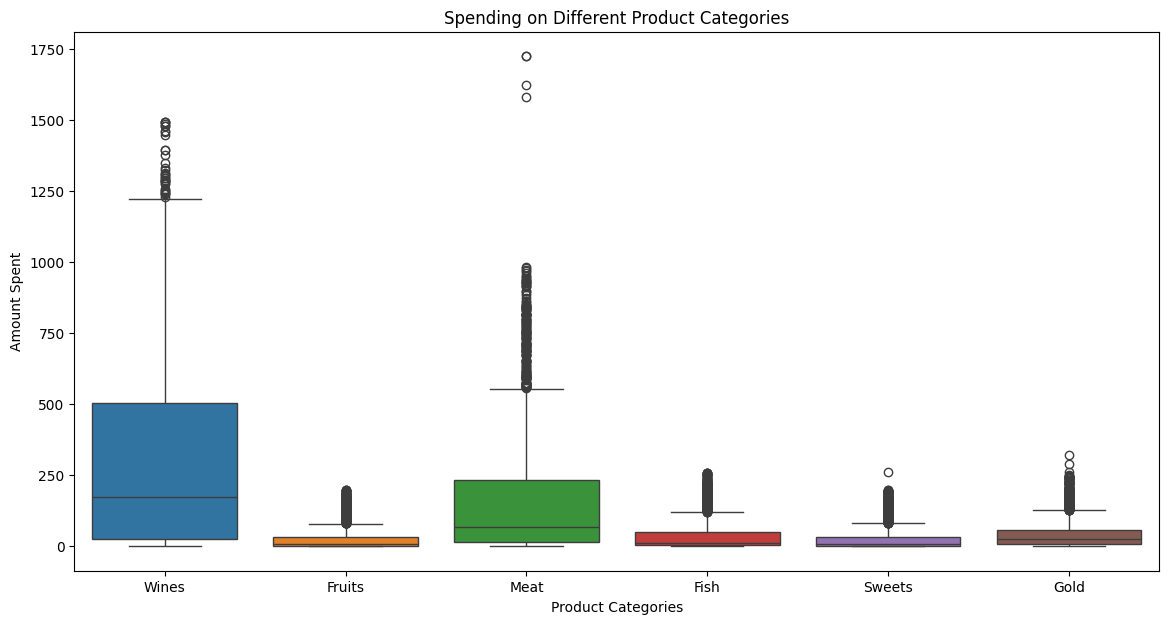

In [96]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=data[['Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']])
plt.title('Spending on Different Product Categories')
plt.xlabel('Product Categories')
plt.ylabel('Amount Spent')
plt.show()

**Cohabitation status bar**

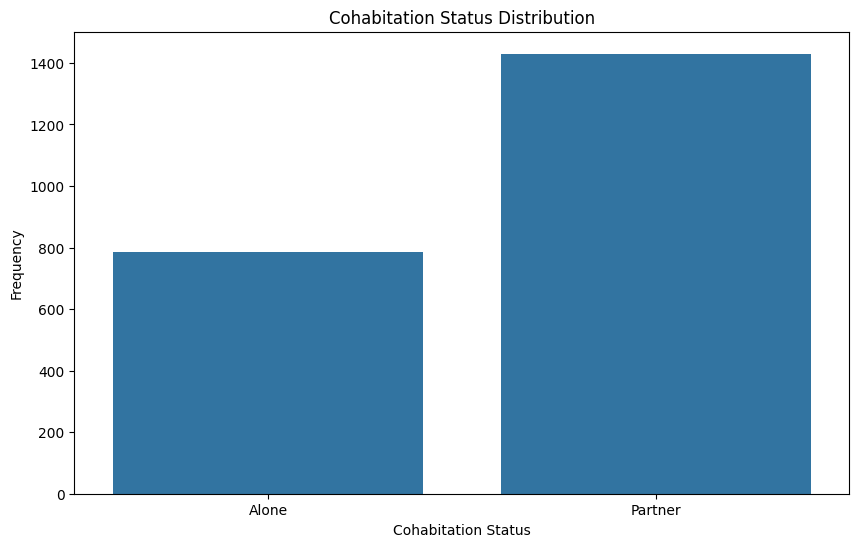

In [97]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Cohabit')
plt.title('Cohabitation Status Distribution')
plt.xlabel('Cohabitation Status')
plt.ylabel('Frequency')
plt.show()

**Education level distribution bar**

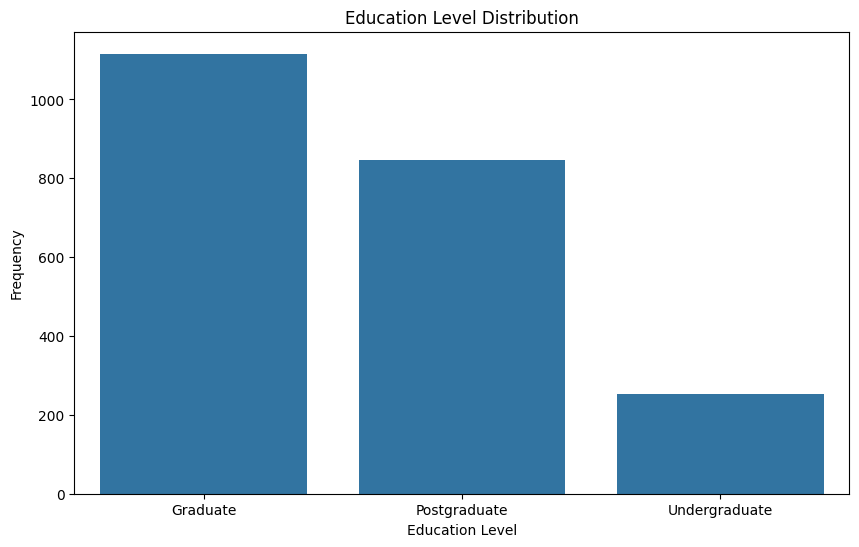

In [98]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Education')
plt.title('Education Level Distribution')
plt.xlabel('Education Level')
plt.ylabel('Frequency')
plt.show()

The histogram of customer ages reveals a bell-shaped distribution centered around 45-50 years, highlighting a mature customer base. The income histogram indicates that most customers earn a lower to middle income, with a long tail representing high-income earners. Additionally, the graph comparing educational levels shows that postgraduate and graduate consumers spend more than undergraduate consumers. Boxplots illustrate spending trends across various product categories, emphasising higher expenditures on wines and meats. According to the bar graph, most customers live with partners, and the major spenders are well-educated.

## Statistical Analysis

Multiple Regression:

In [99]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

Mean Squared Error: 74247.89132866167
R-squared: 0.7187232791948747


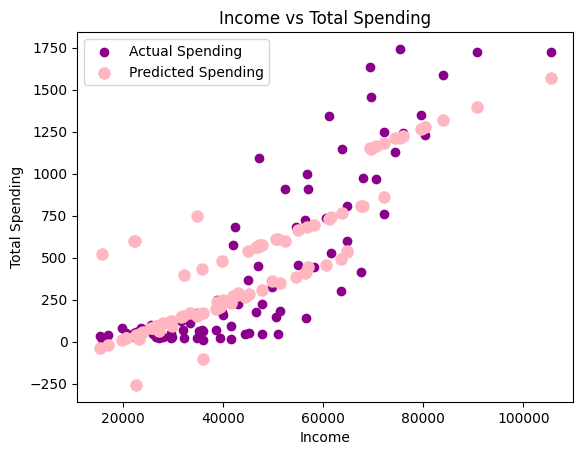

In [100]:
X = data[['Income', 'no.member', 'Is_Parent', 'Kidhome', 'Teenhome']]
y = data['Spent']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.038, random_state=0)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

plt.scatter(X_test['Income'], y_test, color='darkmagenta', label='Actual Spending')
plt.scatter(X_test['Income'], y_pred, color='lightpink', label='Predicted Spending', linewidth=3)
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.title('Income vs Total Spending')
plt.legend()

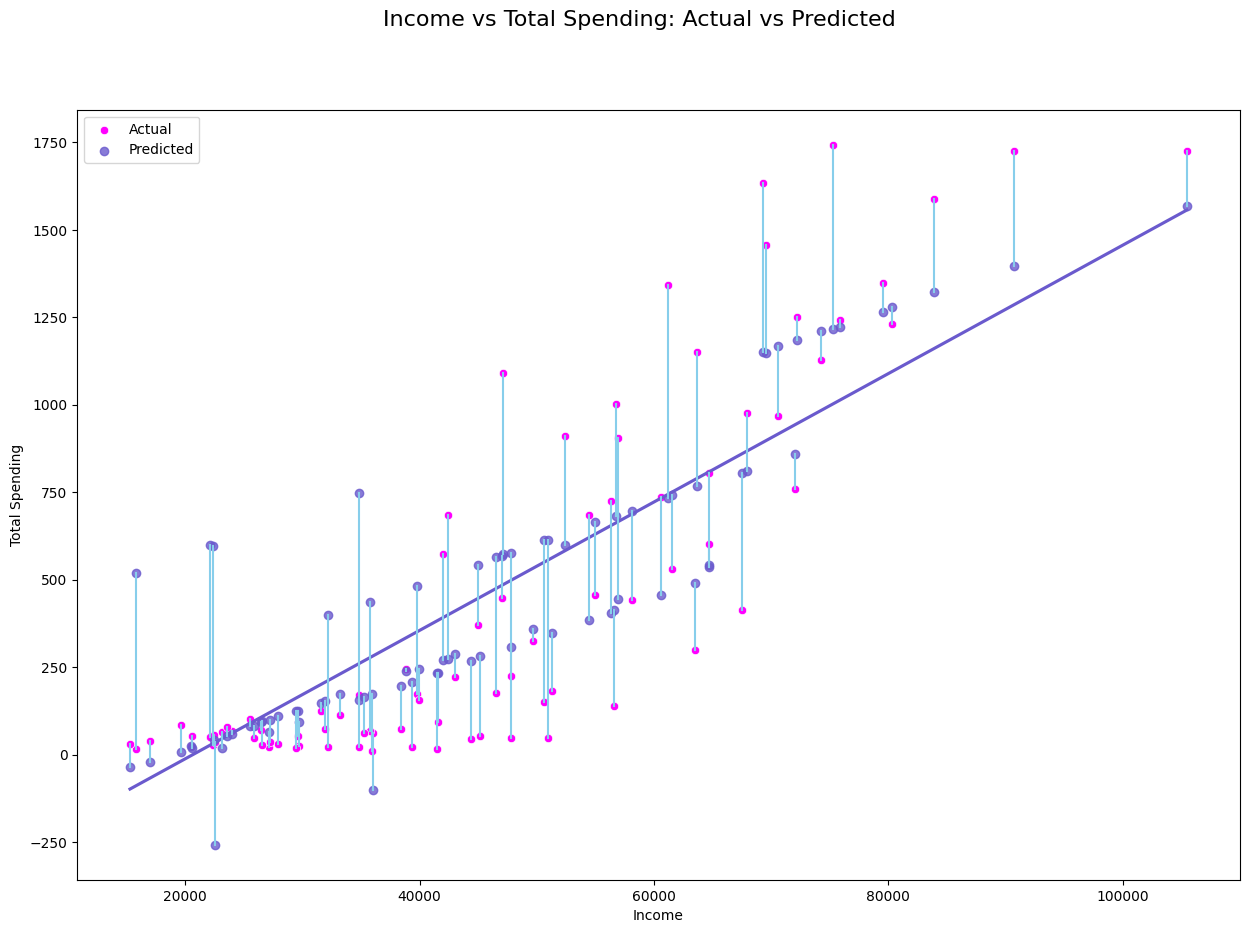

In [101]:
x_test = X_test['Income']

# Convert y_pred to a Pandas Series to use iloc
predictions = pd.Series(y_pred, index=X_test.index)

fig, ax = plt.subplots(figsize=(15, 10))

# Plot the actual data
sns.scatterplot(x=x_test, y=y_test, ax=ax, label='Actual', color='fuchsia')
# Plot the regression line
sns.regplot(x=x_test, y=predictions, fit_reg=True, ci=None, ax=ax, label='Predicted', color='slateblue')
ax.legend()
fig.suptitle('Income vs Total Spending: Actual vs Predicted', fontsize=16)

# Add the residuals
for i in range(x_test.size):
    plt.plot([x_test.iloc[i], x_test.iloc[i]], [y_test.iloc[i], predictions.iloc[i]], color='skyblue')

plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.show()

**Multiple Linear Regression Results:**
+ Mean Squared Error (MSE): 74247.89132866167
- R-squared (R²): 0.7187232791948747

The results of the multiple linear regression model indicate that both income and family size significantly influence spending on products.
The conclusion: The result of the multiple linear regression model indicates that income and family size significantly influence spending on products. Customers with higher incomes and larger families are more likely to spend more. The r-squared value, which is around 0.72, can indicate the high level of correlation between the total spend and both income and family size, which means that around 72% of the variance in the total spend can be explained by the independent variables (Income and Family Size). Because of the strong R-squared value, the overall support for the hypothesis is not considerably affected even though the MSE indicates some prediction errors.


## Predictive Modeling

Logistic Regression:

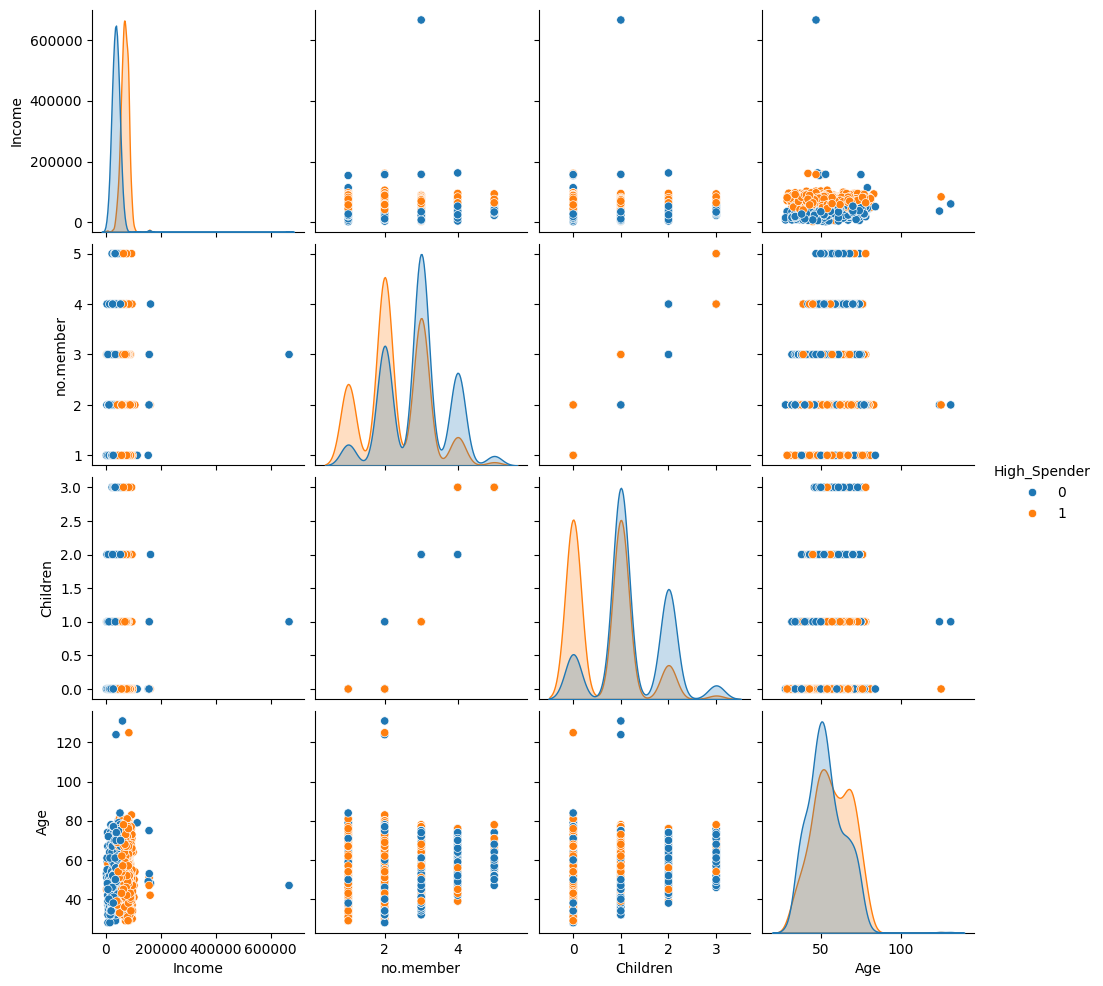

In [102]:
threshold = data['Spent'].median()
data['High_Spender'] = np.where(data['Spent'] > threshold, 1, 0)
X = data[['Income', 'no.member', 'Is_Parent', 'Kidhome', 'Teenhome', 'Age']]
y = data['High_Spender']
sns.pairplot(data, vars=['Income', 'no.member', 'Children', 'Age'], hue='High_Spender')
plt.show()

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.038, random_state=0)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
precision_recall_fscore_support(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

In [105]:
print(accuracy)

0.8823529411764706


**Confusion Matrix**

In [109]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

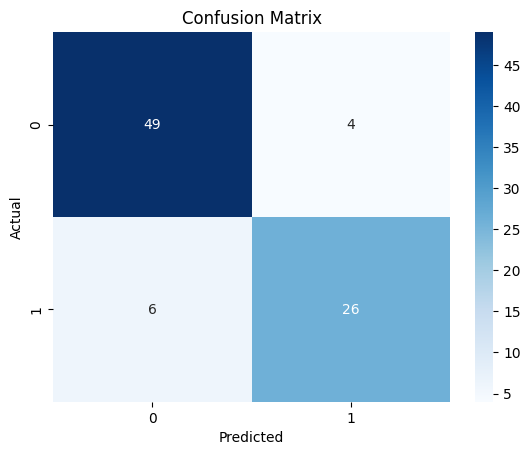

In [110]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Logistic Regression Results**:
- Accuracy: 0.8823529411764706 0 1
- precision: 0.89090909, 0.86666667
 - recall: 0.9245283, 0.8125
- f1-score: 0.90740741, 0.83870968
- support: 53, 32

**Model Performance**:
- Precision: The model shows a precision of 0.89 for identifying high spenders and 0.87 for non-spenders, indicating that the model reliably distinguishes between high spenders and non-spenders.
- Recall: The recall scores of 0.92 for high spenders and 0.81 for non-spenders suggest that the model is particularly effective at identifying high spenders while maintaining a reasonable balance for non-spenders.
- F1-Score: The F1-scores of 0.91 for high spenders and 0.84 for non-spenders reflect a strong balance between precision and recall, demonstrating the model's reliability in predicting both classes.

**The conclusion**: The logistic regression model performs well in forecasting whether a consumer is a high spender based on income, family size, and other characteristics. The model shows a high level of correctness of the predictions with an accuracy of 88.24%. The precision, recall, and F1-scores for both classes indicate that the model is reliable for identifying high spenders. The confusion matrix shows that most predictions are accurate, with a few misclassifications. Thus, the model supports the hypothesis that customers with higher income levels and larger families are more likely to spend more.


**Implications for Supermarkets:**

This model provides actionable insights for supermarkets to identify and target high-spending customers. By focusing marketing efforts on customers with higher income levels and larger families, supermarkets can enhance their promotional strategies and optimize their product offerings to meet the needs of their most profitable customer segments.


## The Conclusion

Overall, this report demonstrates that analyzing income and family size can significantly enhance our understanding of consumer spending behaviors in supermarkets. Through statistical analysis, exploratory data analysis (EDA), and predictive modeling, the study reveals that the customer base is predominantly mature, with ages centered around 45-50 years. Most customers are in the lower to middle-income brackets, with many holding postgraduate and graduate degrees. The hypothesis that customers with higher incomes and larger families tend to spend more on supermarket products is strongly supported by the data. The findings of this study provide actionable strategies for supermarkets to improve their marketing efforts and better meet customer needs, ultimately leading to more effective business practices and greater success in the retail sector.